# Customer Churn Prediction — Model Training

**Goal:** Train, evaluate and select the best churn prediction model.

**Inputs:** Processed train/test splits from `02_feature_engineering.ipynb`

---
**Notebook structure:**
1. Load processed data
2. Baseline model (DummyClassifier)
3. XGBoost — cross-validated training
4. LightGBM — cross-validated training
5. Model comparison
6. Final model evaluation on test set
7. SHAP feature importance
8. Save final model

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import mlflow
import mlflow.sklearn

from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer, roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay, classification_report,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../reports/figures')
MODELS_DIR    = Path('../saved_models')

print('Libraries loaded.')

Libraries loaded.


## 1. Load Processed Data

In [2]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape}  |  churn rate: {y_train.mean()*100:.1f}%')
print(f'Test : {X_test.shape}   |  churn rate: {y_test.mean()*100:.1f}%')

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}  (neg={neg}, pos={pos})')

# Preprocessor is rebuilt from scratch instead of loaded from pickle.
# A pickle-loaded ColumnTransformer cannot be cloned across worker processes
# when cross_validate runs with n_jobs > 1, which causes silent NaN scores.
NUM_COLS = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'total_services', 'charge_per_service',
    'has_security', 'is_long_contract'
]
CAT_COLS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
    'tenure_group'
]

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('cat', cat_pipe, CAT_COLS),
], remainder='drop')

print('Preprocessor ready.')

Train: (5634, 24)  |  churn rate: 26.5%
Test : (1409, 24)   |  churn rate: 26.5%
scale_pos_weight: 2.77  (neg=4139, pos=1495)
Preprocessor ready.


In [3]:
SCORERS = {
    'roc_auc':  make_scorer(roc_auc_score,          response_method='predict_proba'),
    'avg_prec': make_scorer(average_precision_score, response_method='predict_proba'),
}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_cv(pipeline, X, y, label):
    """Run 5-fold CV and return a summary dict."""
    # n_jobs=1 keeps cross_validate in a single process so sklearn can clone
    # the pipeline correctly without multiprocessing serialization issues.
    results = cross_validate(
        pipeline, X, y,
        cv=CV, scoring=SCORERS,
        return_train_score=True, n_jobs=1,
        error_score='raise'
    )
    summary = {'model': label}
    for metric in SCORERS:
        test_scores  = results[f'test_{metric}']
        train_scores = results[f'train_{metric}']
        summary[f'{metric}_mean'] = round(float(test_scores.mean()), 4)
        summary[f'{metric}_std']  = round(float(test_scores.std()),  4)
        summary[f'{metric}_gap']  = round(float(train_scores.mean() - test_scores.mean()), 4)
    return summary

print('CV helper ready.')

CV helper ready.


## 2. Baseline Model

A DummyClassifier always predicts the majority class.  
Every real model must beat this — otherwise the model has learned nothing.

In [4]:
dummy_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=42)),
])

dummy_summary = run_cv(dummy_pipeline, X_train, y_train, 'Dummy (majority class)')
print('Baseline CV results:')
pd.DataFrame([dummy_summary])

Baseline CV results:


,model,roc_auc_mean,roc_auc_std,roc_auc_gap,avg_prec_mean,avg_prec_std,avg_prec_gap
0,Dummy (majority class),0.5,0.0,0.0,0.2654,0.0001,-0.0


## 3. XGBoost

In [5]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
)

xgb_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', xgb_model),
])

xgb_summary = run_cv(xgb_pipeline, X_train, y_train, 'XGBoost')
print('XGBoost CV results:')
pd.DataFrame([xgb_summary])

XGBoost CV results:


,model,roc_auc_mean,roc_auc_std,roc_auc_gap,avg_prec_mean,avg_prec_std,avg_prec_gap
0,XGBoost,0.8263,0.0084,0.1674,0.6307,0.0112,0.3482


## 4. LightGBM

In [6]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', lgb_model),
])

lgb_summary = run_cv(lgb_pipeline, X_train, y_train, 'LightGBM')
print('LightGBM CV results:')
pd.DataFrame([lgb_summary])

LightGBM CV results:


,model,roc_auc_mean,roc_auc_std,roc_auc_gap,avg_prec_mean,avg_prec_std,avg_prec_gap
0,LightGBM,0.8331,0.0086,0.1467,0.6387,0.0166,0.2962


## 5. Model Comparison

In [7]:
results_df = pd.DataFrame([dummy_summary, xgb_summary, lgb_summary])
results_df = results_df.set_index('model')

print('=== CV Comparison ===')
display_cols = ['avg_prec_mean', 'avg_prec_std', 'avg_prec_gap',
                'roc_auc_mean', 'roc_auc_std', 'roc_auc_gap']
results_df[display_cols].round(4)

=== CV Comparison ===


,avg_prec_mean,avg_prec_std,avg_prec_gap,roc_auc_mean,roc_auc_std,roc_auc_gap
model,,,,,,
Dummy (majority class),0.2654,0.0001,-0.0000,0.5000,0.0000,0.0000
XGBoost,0.6307,0.0112,0.3482,0.8263,0.0084,0.1674
LightGBM,0.6387,0.0166,0.2962,0.8331,0.0086,0.1467


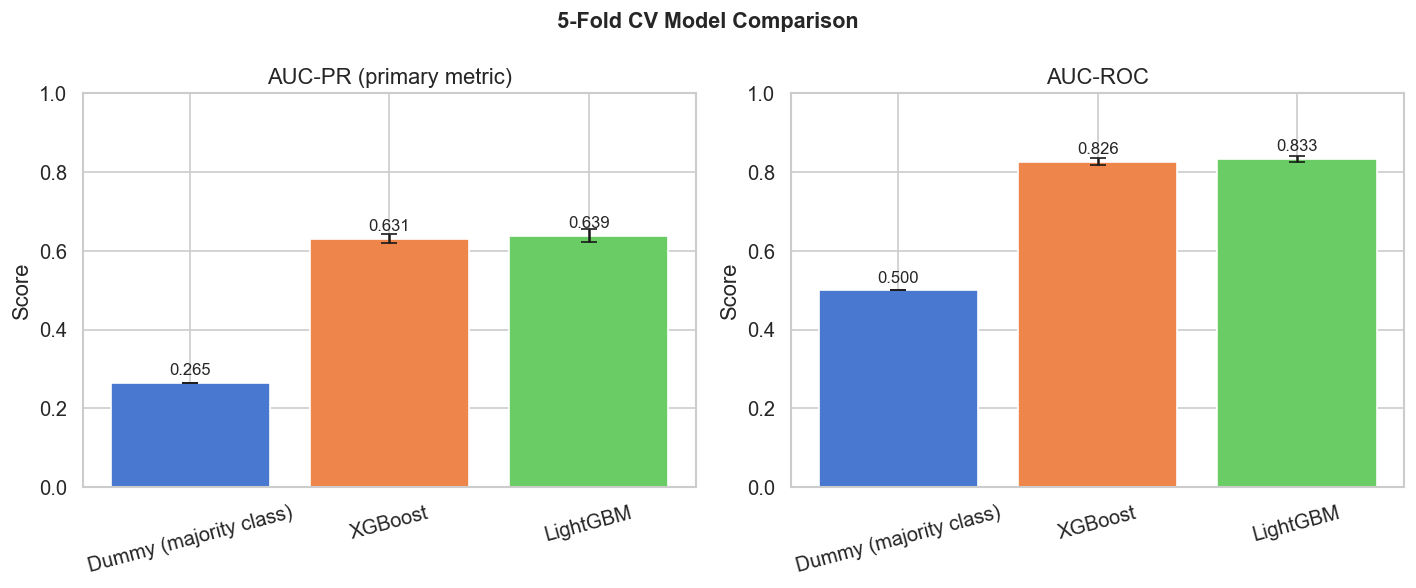

Best model by AUC-PR: LightGBM


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, title in zip(
    axes,
    ['avg_prec_mean', 'roc_auc_mean'],
    ['AUC-PR (primary metric)', 'AUC-ROC']
):
    bars = ax.bar(
        results_df.index,
        results_df[metric],
        color=sns.color_palette('muted', len(results_df)),
        yerr=results_df[metric.replace('mean', 'std')],
        capsize=5
    )
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=10
        )

plt.suptitle('5-Fold CV Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '13_model_comparison_cv.png', dpi=150)
plt.show()

# idxmax() is called on real models only — excludes the dummy baseline
# so it cannot return NaN even if dummy produced a degenerate score.
real_models = results_df.drop(index='Dummy (majority class)', errors='ignore')
best_model_name = str(real_models['avg_prec_mean'].idxmax())
print(f'Best model by AUC-PR: {best_model_name}')

## 6. Final Model Evaluation on Test Set

The test set is used **once** here — at the very end.  
Using it earlier would make the test score an optimistic estimate.

In [9]:
best_pipeline = xgb_pipeline if best_model_name == 'XGBoost' else lgb_pipeline
best_pipeline.fit(X_train, y_train)

y_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

test_auc_roc = roc_auc_score(y_test, y_proba)
test_auc_pr  = average_precision_score(y_test, y_proba)
test_brier   = brier_score_loss(y_test, y_proba)

print(f'Test AUC-ROC : {test_auc_roc:.4f}')
print(f'Test AUC-PR  : {test_auc_pr:.4f}  <- primary metric')
print(f'Test Brier   : {test_brier:.4f}   <- lower is better')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Test AUC-ROC : 0.8295
Test AUC-PR  : 0.6357  <- primary metric
Test Brier   : 0.1615   <- lower is better

              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1035
       Churn       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



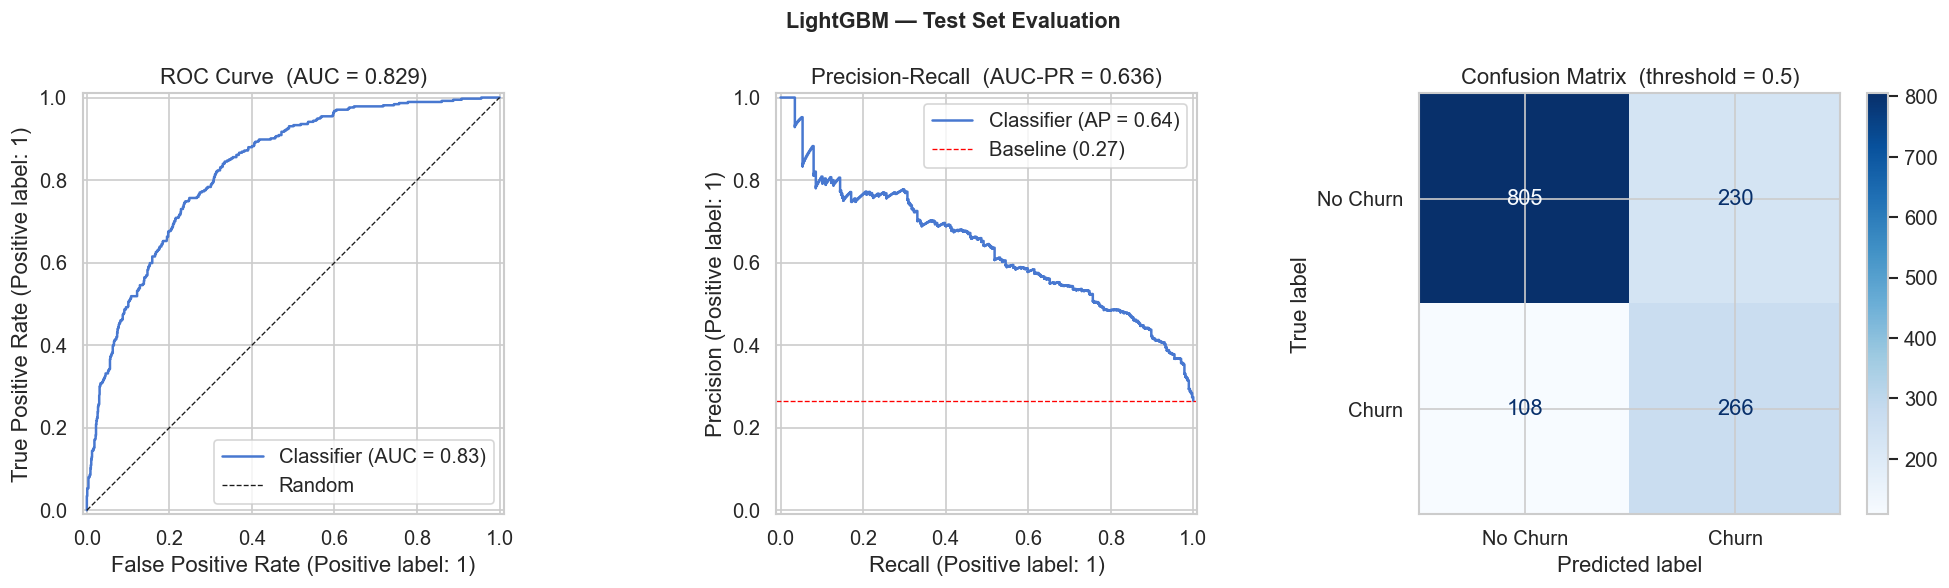

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title(f'ROC Curve  (AUC = {test_auc_roc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
axes[0].legend()

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f'Precision-Recall  (AUC-PR = {test_auc_pr:.3f})')
baseline = y_test.mean()
axes[1].axhline(baseline, color='red', linestyle='--',
                linewidth=0.8, label=f'Baseline ({baseline:.2f})')
axes[1].legend()

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=axes[2]
)
axes[2].set_title('Confusion Matrix  (threshold = 0.5)')

plt.suptitle(f'{best_model_name} — Test Set Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '14_test_evaluation.png', dpi=150)
plt.show()

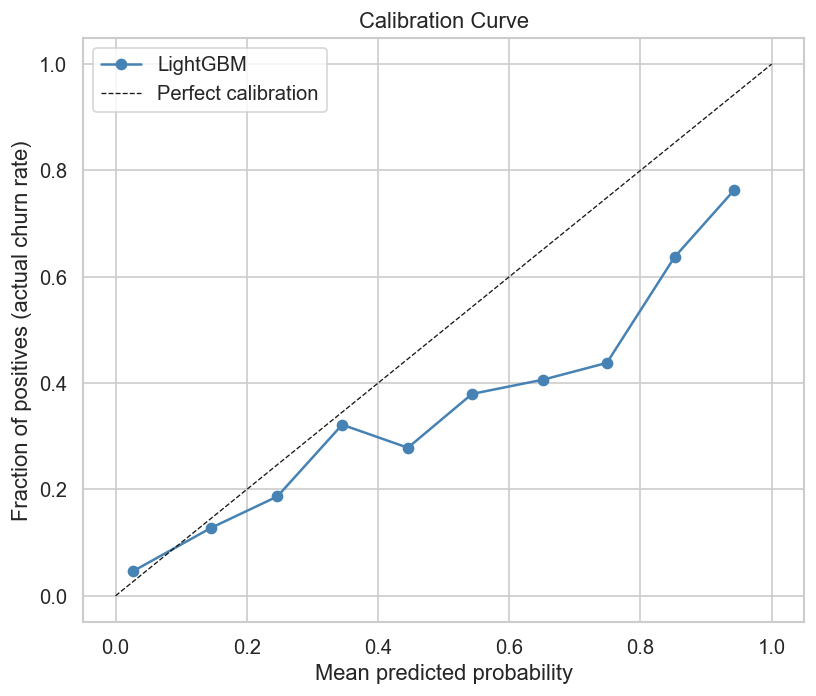

In [11]:
# Calibration curve — checks if predicted probabilities are trustworthy
# A well-calibrated model: predicted 0.7 means ~70% of those customers actually churn
fraction_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_pred, fraction_pos, marker='o', label=best_model_name, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives (actual churn rate)')
ax.set_title('Calibration Curve')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '15_calibration_curve.png', dpi=150)
plt.show()

# If the curve is far from the diagonal, calibration with Platt scaling
# or isotonic regression should be applied before production use.

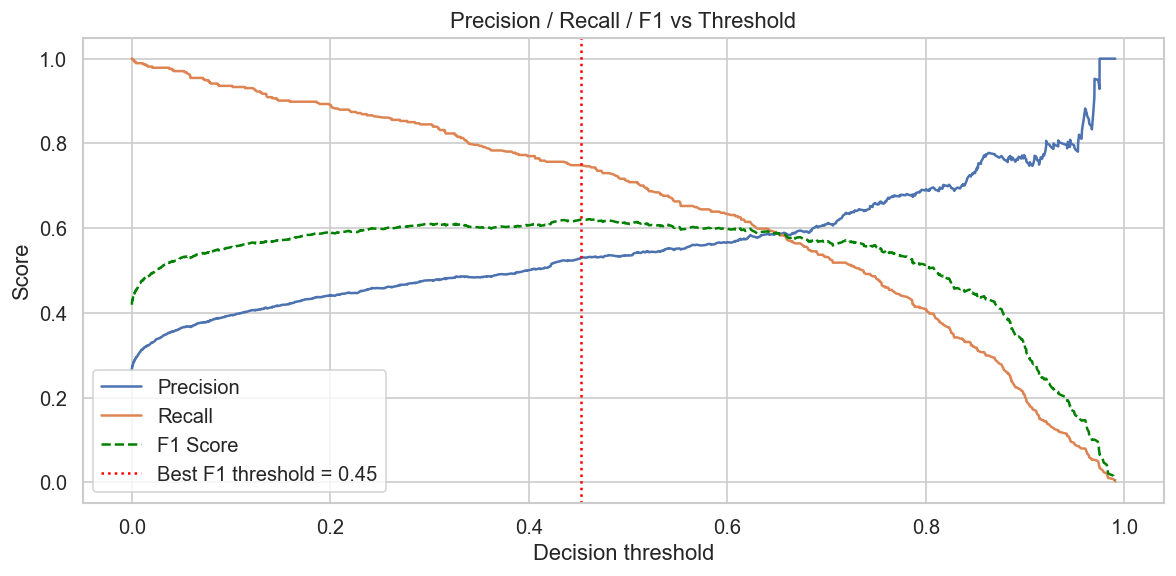

Threshold that maximises F1 on test set: 0.453


In [12]:
# Threshold sensitivity — precision and recall at different cut-offs
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#4C72B0')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='#DD8452')
ax.plot(thresholds, f1_scores[:-1],  label='F1 Score',  color='green', linestyle='--')

# Mark the threshold that maximises F1
best_thresh_idx = f1_scores[:-1].argmax()
best_thresh = thresholds[best_thresh_idx]
ax.axvline(best_thresh, color='red', linestyle=':', linewidth=1.5,
           label=f'Best F1 threshold = {best_thresh:.2f}')

ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '16_threshold_sensitivity.png', dpi=150)
plt.show()

print(f'Threshold that maximises F1 on test set: {best_thresh:.3f}')

## 7. SHAP Feature Importance

SHAP explains **why** the model made each prediction.  
Global importance shows which features matter most overall.  
A local waterfall plot shows a single prediction broken down.

In [13]:
model        = best_pipeline.named_steps['model']
preprocessor_fitted = best_pipeline.named_steps['prep']

X_test_transformed = preprocessor_fitted.transform(X_test)
feature_names      = preprocessor_fitted.get_feature_names_out()

# TreeExplainer is fast and exact for tree-based models
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (1409, 53)


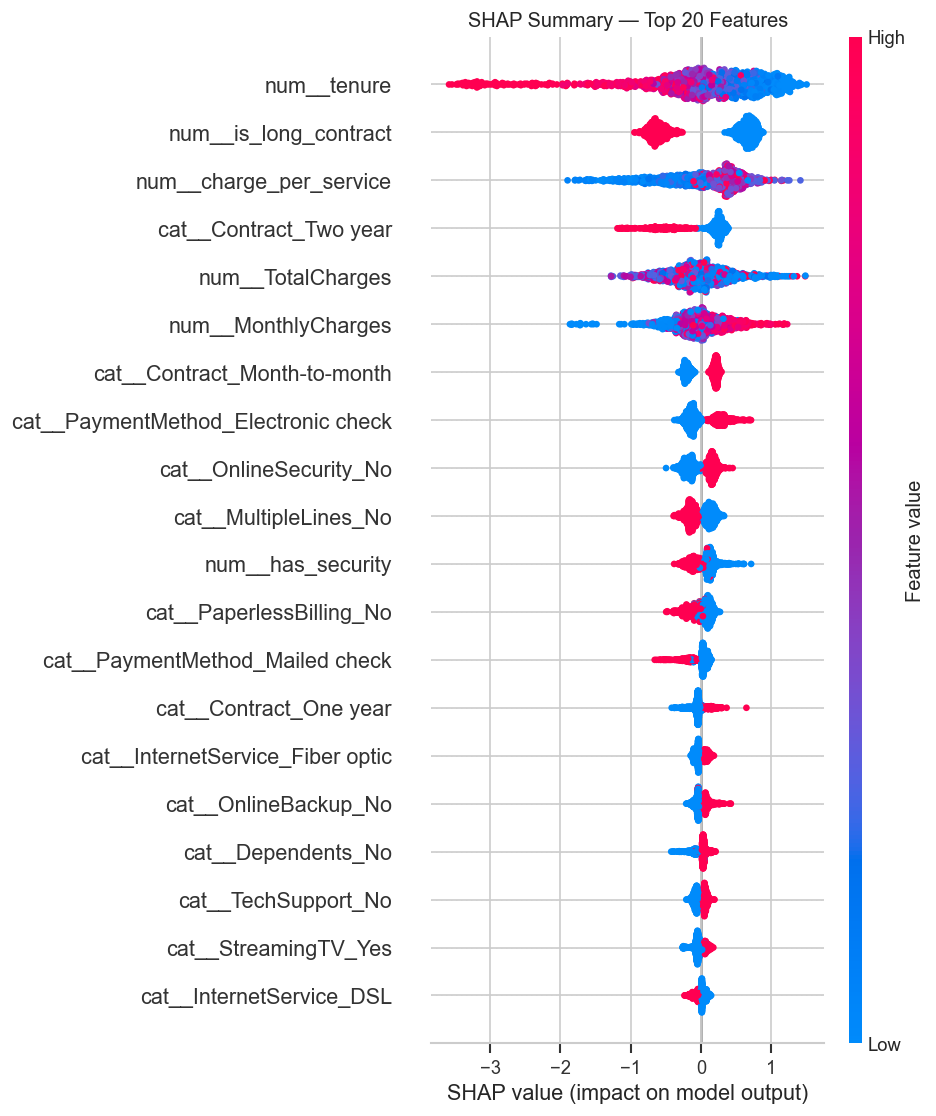

In [14]:
# Global summary plot — top 20 features by mean |SHAP|
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Top 20 Features', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '17_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Red dots = high feature value pushes prediction toward churn.
# Blue dots = low feature value pushes prediction away from churn.

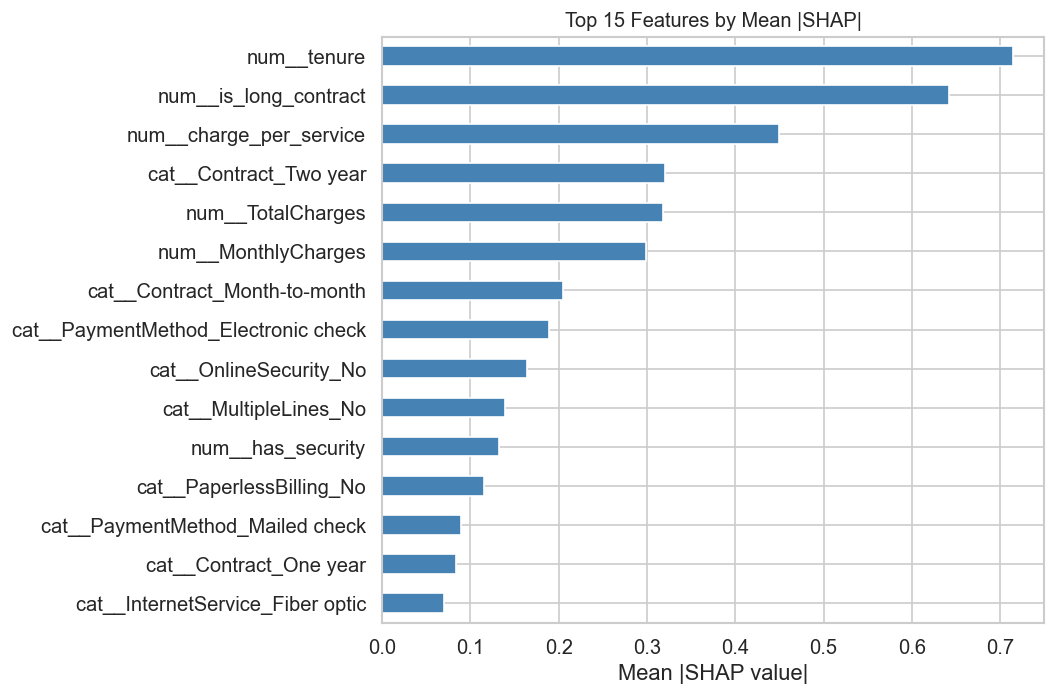

In [15]:
# Bar plot — mean absolute SHAP values (cleaner for presentations)
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = (
    pd.Series(mean_shap, index=feature_names)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
shap_df.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 15 Features by Mean |SHAP|', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '18_shap_bar.png', dpi=150)
plt.show()

Most at-risk customer (index 1109):
  Predicted churn probability : 0.991
  Actual churn                : 1


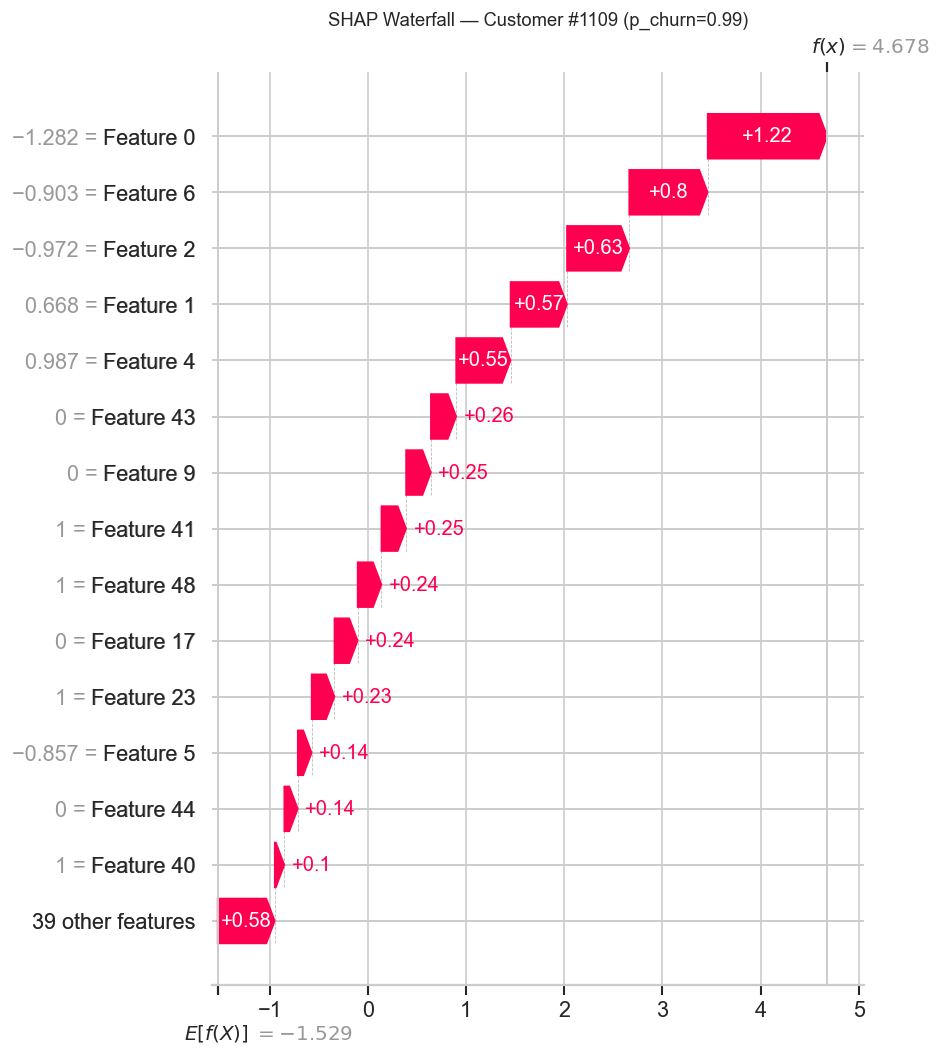

In [16]:
# Local explanation — show prediction breakdown for one high-risk customer
# Pick the customer the model is most confident will churn
high_risk_idx = y_proba.argmax()
print(f'Most at-risk customer (index {high_risk_idx}):')
print(f'  Predicted churn probability : {y_proba[high_risk_idx]:.3f}')
print(f'  Actual churn                : {y_test.iloc[high_risk_idx]}')

shap_explanation = explainer(X_test_transformed)

plt.figure(figsize=(12, 5))
shap.plots.waterfall(shap_explanation[high_risk_idx], max_display=15, show=False)
plt.title(f'SHAP Waterfall — Customer #{high_risk_idx} (p_churn={y_proba[high_risk_idx]:.2f})',
          fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '19_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Log to MLflow & Save Model

In [17]:
mlflow.set_experiment('customer-churn-prediction')

with mlflow.start_run(run_name=f'{best_model_name}_final'):
    # Log hyperparameters
    mlflow.log_params(model.get_params())

    # Log test metrics
    mlflow.log_metrics({
        'test_roc_auc': round(test_auc_roc, 4),
        'test_auc_pr' : round(test_auc_pr,  4),
        'test_brier'  : round(test_brier,   4),
    })

    # Log model artifact
    mlflow.sklearn.log_model(best_pipeline, 'churn_pipeline')

    # Log figures
    for fig_path in sorted(FIGURES_DIR.glob('*.png')):
        mlflow.log_artifact(str(fig_path), artifact_path='figures')

    run_id = mlflow.active_run().info.run_id

print(f'MLflow run logged. Run ID: {run_id}')

2026/06/13 18:24:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/13 18:24:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged. Run ID: e1b3bfcc30a24f39914d0854ed7aa4e7


In [18]:
# Save pipeline as pickle for FastAPI serving
model_path = MODELS_DIR / 'churn_pipeline.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_pipeline, f)

print(f'Model saved to: {model_path}')
print(f'File size     : {model_path.stat().st_size / 1024:.1f} KB')

Model saved to: ../saved_models/churn_pipeline.pkl
File size     : 1434.0 KB


## 9. Summary

In [19]:
print(f"""
=== MODEL TRAINING SUMMARY ===

MODELS TRAINED:
  Dummy baseline    — AUC-PR: {dummy_summary['avg_prec_mean']:.4f}  (floor)
  XGBoost           — AUC-PR: {xgb_summary['avg_prec_mean']:.4f} ± {xgb_summary['avg_prec_std']:.4f}
  LightGBM          — AUC-PR: {lgb_summary['avg_prec_mean']:.4f} ± {lgb_summary['avg_prec_std']:.4f}

WINNER: {best_model_name}

TEST SET RESULTS ({best_model_name}):
  AUC-PR  : {test_auc_pr:.4f}   ← primary metric
  AUC-ROC : {test_auc_roc:.4f}
  Brier   : {test_brier:.4f}
  Best F1 threshold: {best_thresh:.3f}

TOP SHAP FEATURES:
  {chr(10).join(f'  {i+1}. {name}' for i, name in enumerate(shap_df.index[:5]))}

ARTIFACTS SAVED:
  saved_models/churn_pipeline.pkl
  reports/figures/13 to 19 (evaluation + SHAP plots)
  MLflow run: {run_id}

NEXT STEP:
  src/serving/app.py — FastAPI endpoint is already in place.
  Run: uvicorn src.serving.app:app --reload
""")


=== MODEL TRAINING SUMMARY ===

MODELS TRAINED:
  Dummy baseline    — AUC-PR: 0.2654  (floor)
  XGBoost           — AUC-PR: 0.6307 ± 0.0112
  LightGBM          — AUC-PR: 0.6387 ± 0.0166

WINNER: LightGBM

TEST SET RESULTS (LightGBM):
  AUC-PR  : 0.6357   ← primary metric
  AUC-ROC : 0.8295
  Brier   : 0.1615
  Best F1 threshold: 0.453

TOP SHAP FEATURES:
    1. num__tenure
  2. num__is_long_contract
  3. num__charge_per_service
  4. cat__Contract_Two year
  5. num__TotalCharges

ARTIFACTS SAVED:
  saved_models/churn_pipeline.pkl
  reports/figures/13 to 19 (evaluation + SHAP plots)
  MLflow run: e1b3bfcc30a24f39914d0854ed7aa4e7

NEXT STEP:
  src/serving/app.py — FastAPI endpoint is already in place.
  Run: uvicorn src.serving.app:app --reload

